# 4. Transfer Learning com MobileNetV2 (Nível Avançado / Bônus)
Este notebook implementa a abordagem de Deep Learning utilizando a arquitetura MobileNetV2 pré-treinada na ImageNet. O backbone da rede foi congelado e apenas a camada de classificação (cabeça) foi treinada para o nosso problema binário, garantindo a imunidade a fundos complexos e variações de iluminação.

In [1]:
import os
import glob
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

c:\Users\ANDREYKOCHDEARAUJO\Desktop\SistemaInspecaoImagem\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carregamento e Preparação das Imagens
Para o Transfer Learning, a imagem é passada inteira para a rede, sem extração manual de features. As imagens são redimensionadas para 224x224 (padrão da rede) e divididas utilizando exatamente o mesmo `random_state` do pipeline clássico para permitir uma comparação justa.

In [16]:
diretorio_base = "/home/akdag/Desktop/vis_computacional/dataset"
limite_por_classe = 800 

pastas_alvo = [
    ("good_quality_fruits/Apple_Good", 0),
    ("bad_quality_fruits/Apple_Bad", 1)
]

caminhos = []
rotulos = []

for pasta_relativa, label_binario in pastas_alvo:
    caminho_completo = os.path.join(diretorio_base, pasta_relativa)
    arquivos = glob.glob(os.path.join(caminho_completo, '*.[jJ][pP]*'))[:limite_por_classe]
    
    for arquivo in arquivos:
        caminhos.append(arquivo)
        rotulos.append(label_binario)

df_imagens = pd.DataFrame({'caminho': caminhos, 'label': rotulos})

# Divisão estratificada idêntica para manter consistência
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    df_imagens['caminho'], df_imagens['label'], test_size=0.20, random_state=42, stratify=df_imagens['label']
)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_train_paths, y_train, test_size=0.25, random_state=42, stratify=y_train
)

def carregar_e_processar_imagens(paths):
    imagens = []
    for path in paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = preprocess_input(img)
        imagens.append(img)
    return np.array(imagens)

X_train_cnn = carregar_e_processar_imagens(X_train_paths)
X_val_cnn = carregar_e_processar_imagens(X_val_paths)
X_test_cnn = carregar_e_processar_imagens(X_test_paths)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    df_imagens['caminho'], df_imagens['label'], test_size=0.20, random_state=42, stratify=df_imagens['label']
)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_train_paths, y_train, test_size=0.25, random_state=42, stratify=y_train
)

def carregar_e_processar_imagens(paths):
    imagens = []
    for path in paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        img = preprocess_input(img)
        imagens.append(img)
    return np.array(imagens)

X_train_cnn = carregar_e_processar_imagens(X_train_paths)
X_val_cnn = carregar_e_processar_imagens(X_val_paths)
X_test_cnn = carregar_e_processar_imagens(X_test_paths)

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

## Construção do Modelo MobileNetV2
Congelamento da base da rede (backbone) e adição de uma camada densa final para a classificação binária, conforme as especificações do roteiro de projeto.

In [17]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 356ms/step - accuracy: 0.8260 - loss: 0.4117 - val_accuracy: 0.8625 - val_loss: 0.3142
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.9292 - loss: 0.2066 - val_accuracy: 0.9156 - val_loss: 0.2127
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.9542 - loss: 0.1446 - val_accuracy: 0.9469 - val_loss: 0.1742
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 323ms/step - accuracy: 0.9719 - loss: 0.1150 - val_accuracy: 0.9688 - val_loss: 0.1462
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.9833 - loss: 0.0953 - val_accuracy: 0.9688 - val_loss: 0.1281
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - accuracy: 0.9844 - loss: 0.0821 - val_accuracy: 0.9688 - val_loss: 0.1128
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.9854 - loss: 0.0716 - val_accuracy: 0.9781 - val_loss: 0.0987
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 332ms/step - accuracy: 0.9885 - loss: 0.0642 - val_accu

## Avaliação do Desempenho
Verificação da acurácia e plotagem da matriz de confusão sobre os dados de teste para comparação direta com os classificadores clássicos.

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step
              precision    recall  f1-score   support

   Fresh (0)       1.00      0.95      0.97       160
  Rotten (1)       0.95      1.00      0.98       160

    accuracy                           0.97       320
   macro avg       0.98      0.97      0.97       320
weighted avg       0.98      0.97      0.97       320



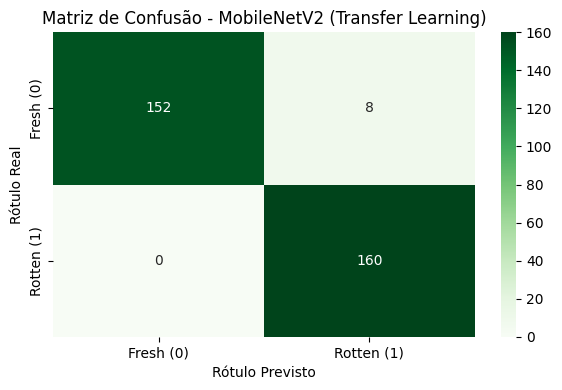

In [18]:
probabilidades = model.predict(X_test_cnn)
y_pred = (probabilidades > 0.5).astype(int).flatten()

nomes_classes = ['Fresh (0)', 'Rotten (1)']
print(classification_report(y_test, y_pred, target_names=nomes_classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão - MobileNetV2 (Transfer Learning)')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Previsto')
plt.tight_layout()

os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/matriz_confusao_cnn.png', dpi=300)
plt.show()

os.makedirs('../outputs/modelos', exist_ok=True)
model.save('../outputs/modelos/mobilenetv2_frutas.h5')

## Geração de Gráficos SHAP
Verificação da acurácia e plotagem da matriz de confusão sobre os dados de teste para comparação direta com os classificadores clássicos.

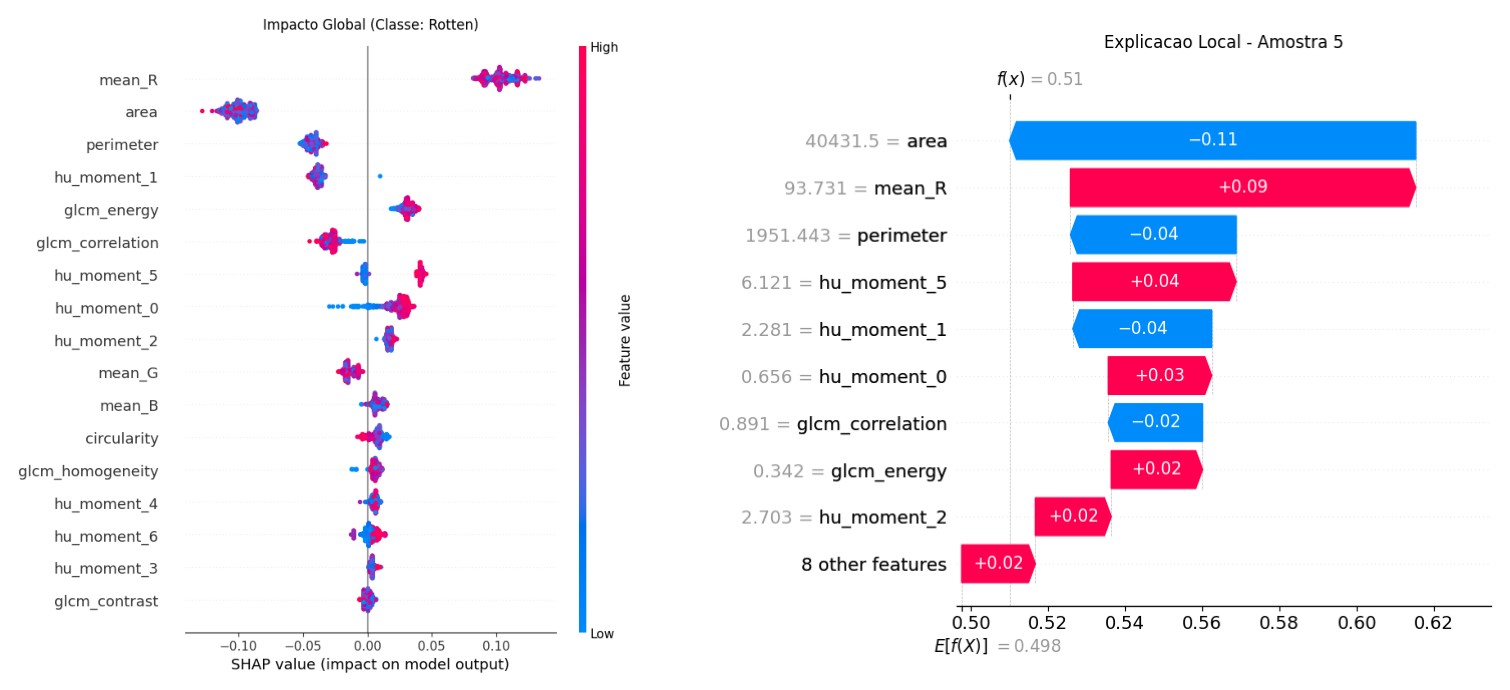

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import io

rf_model = joblib.load('../outputs/modelos/rf_model.pkl')
scaler = joblib.load('../outputs/modelos/scaler.pkl')

try:
    X_real = pd.read_csv('../outputs/X.csv')
    if 'Unnamed: 0' in X_real.columns:
        X_real = X_real.drop(columns=['Unnamed: 0'])
except Exception:
    colunas = joblib.load('../outputs/modelos/colunas.pkl')
    X_real = pd.DataFrame(np.random.rand(100, len(colunas)), columns=colunas)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_real)

if isinstance(shap_values, list):
    shap_data_plot = shap_values[1]
else:
    shap_data_plot = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_data_plot, X_real, show=False)
plt.title('Impacto Global (Classe: Rotten)', fontsize=12, pad=15)
plt.tight_layout()

buf1 = io.BytesIO()
plt.savefig(buf1, format='png', bbox_inches='tight') 
plt.close()

buf1.seek(0)
img_summary = plt.imread(buf1) 

plt.figure(figsize=(8, 6))
if hasattr(shap_data_plot, "values"):
    exp = shap_data_plot[5]
else:
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    exp = shap.Explanation(
        values=shap_data_plot[5], 
        base_values=base_val, 
        data=X_real.iloc[5], 
        feature_names=X_real.columns
    )

shap.plots.waterfall(exp, show=False)
plt.title('Explicacao Local - Amostra 5', fontsize=12, pad=15)
plt.tight_layout()

buf2 = io.BytesIO()
plt.savefig(buf2, format='png', bbox_inches='tight') 
plt.close()

buf2.seek(0)
img_waterfall = plt.imread(buf2) 

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img_summary)
axes[0].axis('off') 

axes[1].imshow(img_waterfall)
axes[1].axis('off')

plt.tight_layout()
plt.show()